In [30]:
import sys
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature
import geopandas as gpd
from shapely.geometry import mapping
from scipy.stats import spearmanr, pearsonr
import ts_onset_cess as ocd
import pandas as pd
from fapar_def import fapar_read

import warnings
warnings.filterwarnings('ignore')

In [31]:
datap = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/"

### Read in calculated recycling to add to the precipitation plots

In [32]:
Y1=1990
Y2=2024

datao = {}
datao['delta_1e-3_max_1000'] = "/Volumes/ESA_F4R/ed_prepare/2026_rho/mint_r02_it1000_tole3/bands_rho/" 
datao['nudged_delta_1e-3_max_1000'] = "/Volumes/ESA_F4R/ed_prepare/2026_rho/nudge_mint_r02_it1000_tole3/"
datao['nudged_delta_1e-2_max_500'] = "/Volumes/ESA_F4R/ed_prepare/2026_rho/nudged_mint_r02_tol1e2_max500/"
datao['nudged_delta_1e-3_max_500'] = "/Volumes/ESA_F4R/ed_prepare/2026_rho/nudged_mint_r02_tol1e3_max500/"
datao['nudged_delta_1e-4_max_1000'] = "/Volumes/ESA_F4R/ed_prepare/2026_rho/nudged_mint_r02_tol1e4_max1000/"
datao['nudged_delta_1e-2_max_1000'] = "/Volumes/ESA_F4R/ed_prepare/2026_rho/nudged_mint_r02_tol1e2_max1000/"

S_NAME = "S_SE" # S_SE or S_LSE 
L_NAME = "L_M" # L_M or L_HI
band = {'N':[5,12,10,31],'EQ':[-5,5,8,29],'S':[-15,-5,12,31]}
rho_xarr={}
for R in datao:
    rho_xarr[R] = {}
    for B in ['N','EQ','S']:
        print(datao[R])
        rho_xarr[R][B] = xr.open_mfdataset(datao[R]+L_NAME+"_"+S_NAME+"_band_"+B+"_rot_rho_era5_*.nc",engine='netcdf4')
        rho_xarr[R][B] = rho_xarr[R][B].sel(time=slice(str(Y1)+'-01-01',str(Y2)+'-12-31'))

/Volumes/ESA_F4R/ed_prepare/2026_rho/mint_r02_it1000_tole3/bands_rho/
/Volumes/ESA_F4R/ed_prepare/2026_rho/mint_r02_it1000_tole3/bands_rho/
/Volumes/ESA_F4R/ed_prepare/2026_rho/mint_r02_it1000_tole3/bands_rho/
/Volumes/ESA_F4R/ed_prepare/2026_rho/nudge_mint_r02_it1000_tole3/
/Volumes/ESA_F4R/ed_prepare/2026_rho/nudge_mint_r02_it1000_tole3/
/Volumes/ESA_F4R/ed_prepare/2026_rho/nudge_mint_r02_it1000_tole3/
/Volumes/ESA_F4R/ed_prepare/2026_rho/nudged_mint_r02_tol1e2_max500/
/Volumes/ESA_F4R/ed_prepare/2026_rho/nudged_mint_r02_tol1e2_max500/
/Volumes/ESA_F4R/ed_prepare/2026_rho/nudged_mint_r02_tol1e2_max500/
/Volumes/ESA_F4R/ed_prepare/2026_rho/nudged_mint_r02_tol1e3_max500/
/Volumes/ESA_F4R/ed_prepare/2026_rho/nudged_mint_r02_tol1e3_max500/
/Volumes/ESA_F4R/ed_prepare/2026_rho/nudged_mint_r02_tol1e3_max500/
/Volumes/ESA_F4R/ed_prepare/2026_rho/nudged_mint_r02_tol1e4_max1000/
/Volumes/ESA_F4R/ed_prepare/2026_rho/nudged_mint_r02_tol1e4_max1000/
/Volumes/ESA_F4R/ed_prepare/2026_rho/nudged_mi

### Calculate roatational means for each month and band


In [33]:
#Monthly average plots - average rotation
rho_mon = {}
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for R in datao:
    rho_mon[R] = {}
    for B in ['N','EQ','S']:
        rho_rot = rho_xarr[R][B]['rho'].mean('rot') 
        rho_mon[R][B] = rho_rot.groupby('time.month').mean(dim=('time','lat','lon'))
        rho_mon[R][B] = rho_mon[R][B].assign_coords(dayofyear=('month', [15,45,74,105,135,166,196,227,258,288,319,349]))
        

### Read in precip 
- do this for whole available ts and then sub-select years in next step for analysis

In [34]:
#Y1=1981
#Y2=2025
#for Y in range(Y1,Y2+1):
#    prp = xr.open_mfdataset('/Volumes/blue_wd/chirps_daily/chirps-v2.0.'+str(Y)+'.days_p05.nc')['precip']
#    prp = prp.rename({'latitude':'lat','longitude':'lon'})
#    prpN = prp.sel(lat=slice(5,12),lon=slice(10,31),drop=True).load()
#    prpEQ = prp.sel(lat=slice(-5,5),lon=slice(8,29),drop=True).load()
#    prpS = prp.sel(lat=slice(-15,-5),lon=slice(12,31),drop=True).load()
#    if Y==Y1:
#        prpaN = prpN
#        prpaEQ = prpEQ
#        prpaS = prpS
#    else:
#        prpaN = xr.concat([prpaN,prpN],dim='time')
#        prpaEQ = xr.concat([prpaEQ,prpEQ],dim='time')
#        prpaS = xr.concat([prpaS,prpS],dim='time')
#        prpN.close()
#        prpEQ.close()
#        prpS.close()
#prpaN.to_netcdf('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_N.nc',engine='h5netcdf')
#prpaN.close()
#prpaEQ.to_netcdf('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_EQ.nc',engine='h5netcdf')
#prpaEQ.close()
#prpaS.to_netcdf('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_S.nc',engine='h5netcdf')
#prpaS.close()
#        

In [35]:
Y1=1990
Y2=2024
pr = {}
prp = xr.open_dataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_N.nc')['precip']
pr['N'] = prp.sel(time=slice(str(Y1)+'-01-01',str(Y2)+'-12-31'))
prp = xr.open_dataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_EQ.nc')['precip']
pr['EQ'] = prp.sel(time=slice(str(Y1)+'-01-01',str(Y2)+'-12-31'))
prp = xr.open_dataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_S.nc')['precip']
pr['S'] = prp.sel(time=slice(str(Y1)+'-01-01',str(Y2)+'-12-31'))


## Equatorial Band

- Checking to see if wet and dry seasons have consistently different onset and cessation dates

- Calculate wet and dry season composites for season 1 and season 2

- Calculate the onset and cessation of full climatology for all seasons

- Calculate onset and cessation of wet and dry composite seasons

- Calculate mean of onset and cessation composites

- Plot everything

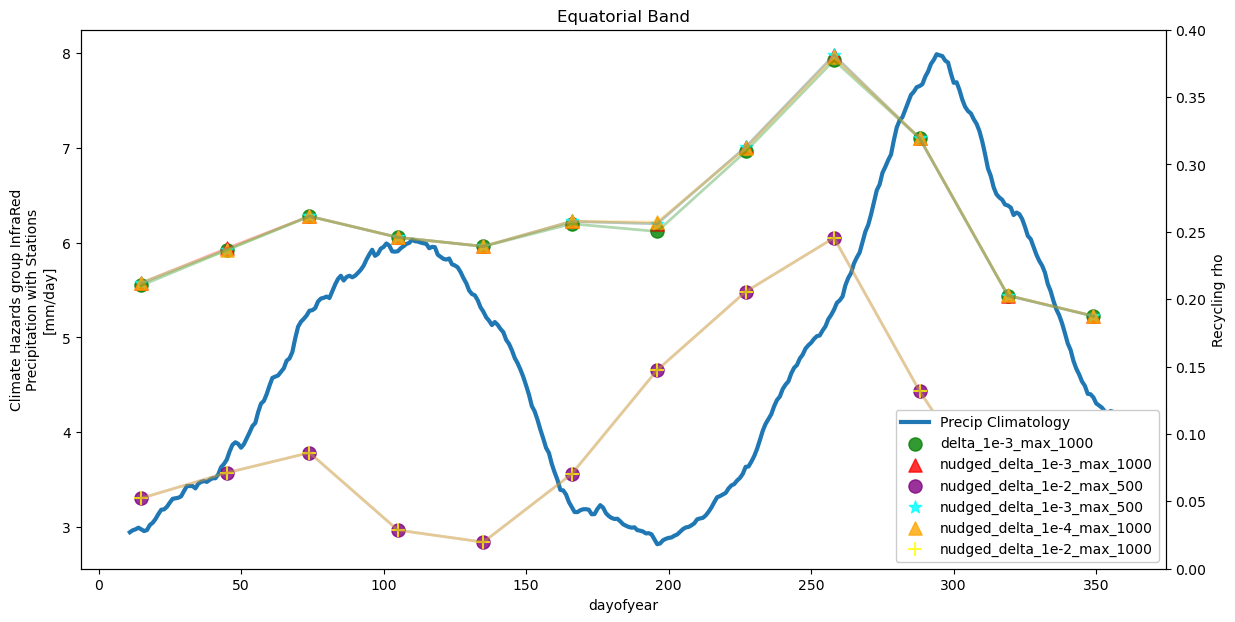

In [39]:
#Equatorial Band

P = pr['EQ'] 

#Plot everything - SEASON 1

fig,ax = plt.subplots(figsize=(14, 7))
Pdays = P.mean(dim = ('lat','lon')).groupby('time.dayofyear').mean(dim = ('time'))
PplotR = Pdays.rolling(dayofyear=20, center=True).mean('dayofyear')
PplotR.plot(linewidth=3,label='Precip Climatology')

ax2 = ax.twinx()

c = ['green','red','purple','cyan','orange','yellow']
m = ['o','^','o','*','^','+']
for i,R in enumerate(datao):
    ax2.plot(rho_mon[R]['EQ']['dayofyear'],rho_mon[R]['EQ'],linestyle='-',linewidth=2,color=c[i],alpha=0.3)
    ax2.scatter(rho_mon[R]['EQ']['dayofyear'],rho_mon[R]['EQ'],s=90,color=c[i],marker=m[i],label=R,alpha=0.8)
ax2.set(ylim=(0,0.4), ylabel='Recycling rho')


# Get the line legends from the axis
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Add a legend to the figure
plt.legend(lines + lines2, labels + labels2 , framealpha=1.0, loc='lower right')

plt.title('Equatorial Band')
plt.savefig(datap+'EQ_recycling_clim.png',dpi=200,transparent=True,bbox_inches='tight')
plt.show()
plt.clf()
plt.close()


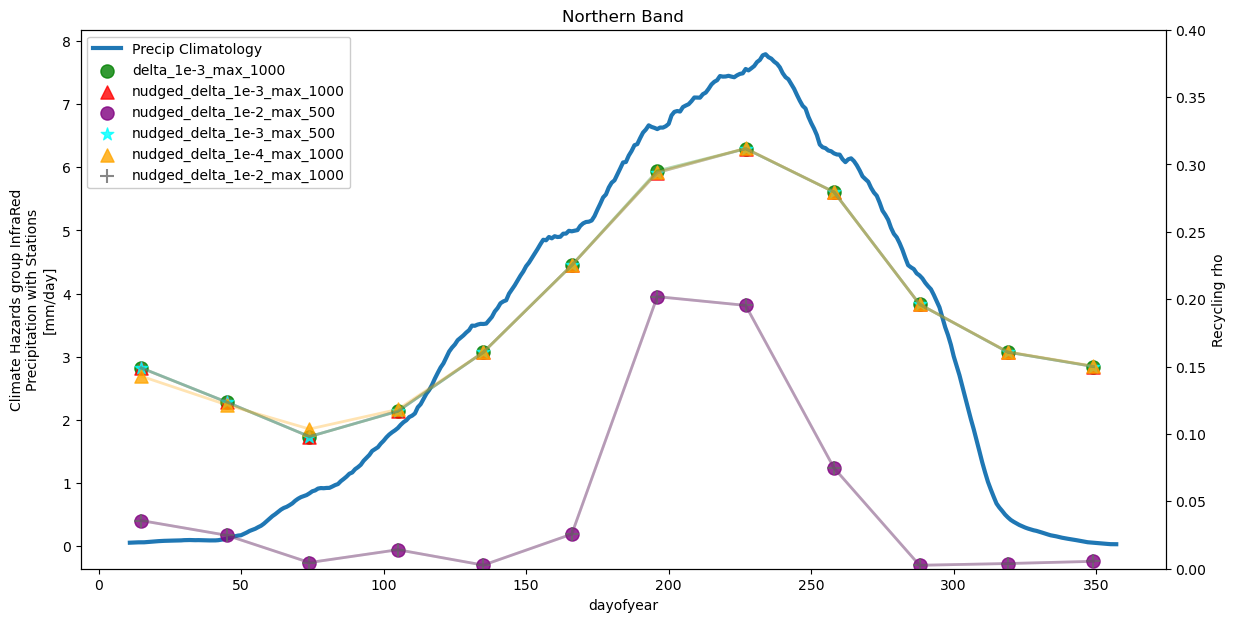

<Figure size 640x480 with 0 Axes>

In [ ]:
#North Band

P = pr['N'] 

#Plot everything - SEASON 1

fig,ax = plt.subplots(figsize=(14, 7))
Pdays = P.mean(dim = ('lat','lon')).groupby('time.dayofyear').mean(dim = ('time'))
PplotR = Pdays.rolling(dayofyear=20, center=True).mean('dayofyear')
PplotR.plot(linewidth=3,label='Precip Climatology')

ax2 = ax.twinx()

c = ['green','red','purple','cyan','orange','yellow']
m = ['o','^','o','*','^','+']
for i,R in enumerate(datao):
    ax2.plot(rho_mon[R]['N']['dayofyear'],rho_mon[R]['N'],linestyle='-',linewidth=2,color=c[i],alpha=0.3)
    ax2.scatter(rho_mon[R]['N']['dayofyear'],rho_mon[R]['N'],s=90,color=c[i],marker=m[i],label=R,alpha=0.8)
ax2.set(ylim=(0,0.4), ylabel='Recycling rho')

# Get the line legends from the axis
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Add a legend to the figure
plt.legend(lines + lines2, labels + labels2, framealpha=1.0, loc='upper left')

plt.title('Northern Band')
plt.savefig(datap+'N_recycling_clim.png',dpi=200,transparent=True,bbox_inches='tight')
plt.show()
plt.clf()

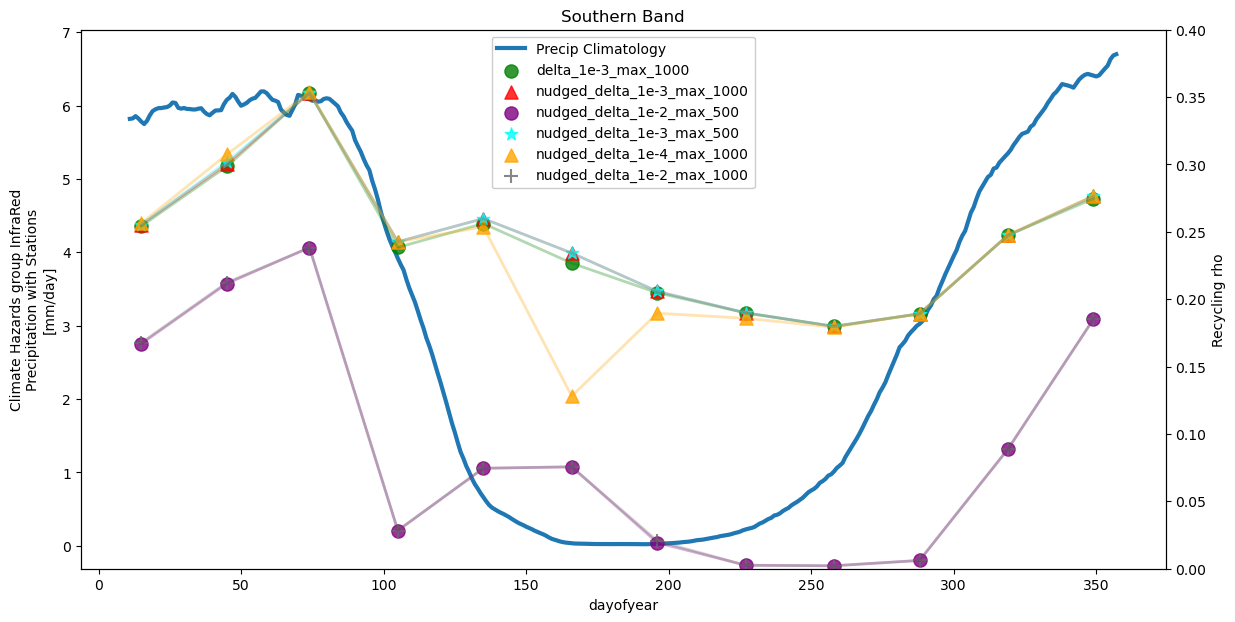

<Figure size 640x480 with 0 Axes>

In [ ]:
#Southern Band

P = pr['S'] 

#Plot everything - SEASON 1

fig,ax = plt.subplots(figsize=(14, 7))
Pdays = P.mean(dim = ('lat','lon')).groupby('time.dayofyear').mean(dim = ('time'))
PplotR = Pdays.rolling(dayofyear=20, center=True).mean('dayofyear')
PplotR.plot(linewidth=3,label='Precip Climatology')

ax2 = ax.twinx()

c = ['green','red','purple','cyan','orange','yellow']
m = ['o','^','o','*','^','+']
for i,R in enumerate(datao):
    ax2.plot(rho_mon[R]['S']['dayofyear'],rho_mon[R]['S'],linestyle='-',linewidth=2,color=c[i],alpha=0.3)
    ax2.scatter(rho_mon[R]['S']['dayofyear'],rho_mon[R]['S'],s=90,color=c[i],marker=m[i],label=R,alpha=0.8)
ax2.set(ylim=(0,0.4), ylabel='Recycling rho')

# Get the line legends from the axis
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Add a legend to the figure
plt.legend(lines + lines2, labels + labels2, framealpha=1.0, loc='upper center')

plt.title('Southern Band')
plt.savefig(datap+'S_recycling_clim.png',dpi=200,transparent=True,bbox_inches='tight')
plt.show()
plt.clf()